# Employee Data Analysis from PDF

## 1. Import Libraries

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tabula

## 2. Load PDF Data ## 3. Extract Tables

In [83]:
tables=tabula.read_pdf(
    "../data/raw/employee_report.pdf",
    pages="all",
    multiple_tables=True
)

Oct 01, 2026 10:14:24 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>
Oct 01, 2026 10:14:24 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>


Oct 01, 2026 10:14:26 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>
Oct 01, 2026 10:14:26 AM org.apache.pdfbox.pdmodel.font.PDType1Font <init>


## 4. Combine Tables

In [84]:
df=pd.concat(tables , ignore_index=True) 
 #Because our PDF has multiple pages, Tabula may return multiple DataFrames. We'll combine them:
#this is for combining diff tables into one df

# 5. Data Understanding

In [85]:
len(tables)

4

In [86]:
df["Salary"].describe()

count        96.000000
mean      93500.000000
std       35149.605074
min       36000.000000
25%       63000.000000
50%       89000.000000
75%      121250.000000
max      160000.000000
Name: Salary, dtype: float64

In [87]:
tables[0].head()

,Emp_ID,Name,Age,Department,Gender,City,Experience,Salary,Performance,Joining_Year
0,1001,Aarav A,42.0,IT,Female,Bangalore,3,63000.0,63,2023
1,1002,Ananya A,45.0,Operations,Male,Pune,3,89000.0,57,2023
2,1003,Rahul A,22.0,HR,Male,Pune,0,112000.0,56,2026
3,1004,Priya A,39.0,Operations,Female,Bangalore,6,92000.0,92,2020
4,1005,Kiran A,30.0,HR,Female,Chennai,0,70000.0,64,2026


In [88]:
tables[0].shape

#tables
#  tables[0] → page 1 table
# tables[1] → page 2 tabl
#  tables[2] → page 3 table

(25, 10)

In [89]:
df.head() #1st 5 rows

,Emp_ID,Name,Age,Department,Gender,City,Experience,Salary,Performance,Joining_Year
0,1001,Aarav A,42.0,IT,Female,Bangalore,3.0,63000.0,63.0,2023
1,1002,Ananya A,45.0,Operations,Male,Pune,3.0,89000.0,57.0,2023
2,1003,Rahul A,22.0,HR,Male,Pune,0.0,112000.0,56.0,2026
3,1004,Priya A,39.0,Operations,Female,Bangalore,6.0,92000.0,92.0,2020
4,1005,Kiran A,30.0,HR,Female,Chennai,0.0,70000.0,64.0,2026


In [90]:
df.tail() #last 5 rows

,Emp_ID,Name,Age,Department,Gender,City,Experience,Salary,Performance,Joining_Year
95,1096,Neha E,47.0,HR,Female,Bangalore,19.0,69000.0,82.0,2007
96,1097,Varun E,37.0,Marketing,Female,Mumbai,0.0,127000.0,65.0,2026
97,1098,Ishita E,48.0,HR,Male,Mumbai,14.0,NaN,91.0,2012
98,1099,Aditya E,43.0,IT,Female,Bangalore,0.0,145000.0,84.0,2026
99,1100,Swathi E,27.0,Finance,Female,Chennai,0.0,62000.0,84.0,2026


In [91]:
df.columns

Index(['Emp_ID', 'Name', 'Age', 'Department', 'Gender', 'City', 'Experience',
       'Salary', 'Performance', 'Joining_Year'],
      dtype='str')

In [92]:
df.shape

(100, 10)

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Emp_ID        100 non-null    int64  
 1   Name          100 non-null    str    
 2   Age           97 non-null     float64
 3   Department    97 non-null     str    
 4   Gender        98 non-null     str    
 5   City          97 non-null     str    
 6   Experience    98 non-null     float64
 7   Salary        96 non-null     float64
 8   Performance   97 non-null     float64
 9   Joining_Year  100 non-null    int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 7.9 KB


In [94]:
df.describe()

,Emp_ID,Age,Experience,Salary,Performance,Joining_Year
count,100.000000,97.000000,98.000000,96.000000,97.000000,100.000000
mean,1050.500000,35.793814,7.714286,93500.000000,79.020619,2018.270000
std,29.011492,8.310308,6.977135,35149.605074,13.018400,6.916318
min,1001.000000,22.000000,0.000000,36000.000000,56.000000,1997.000000
25%,1025.750000,29.000000,2.250000,63000.000000,68.000000,2014.000000
50%,1050.500000,35.000000,6.000000,89000.000000,82.000000,2020.000000
75%,1075.250000,43.000000,12.000000,121250.000000,90.000000,2023.250000
max,1100.000000,50.000000,29.000000,160000.000000,99.000000,2026.000000


# 6. Missing Value Analysis ⭐

In [95]:
df.isnull()

,Emp_ID,Name,Age,Department,Gender,City,Experience,Salary,Performance,Joining_Year
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
95,False,False,False,False,False,False,False,False,False,False
96,False,False,False,False,False,False,False,False,False,False
97,False,False,False,False,False,False,False,True,False,False
98,False,False,False,False,False,False,False,False,False,False


In [96]:
df.isnull().sum()

Emp_ID          0
Name            0
Age             3
Department      3
Gender          2
City            3
Experience      2
Salary          4
Performance     3
Joining_Year    0
dtype: int64

In [97]:
df.isnull().sum().sum()

np.int64(20)

# filling the missing values

In [98]:
df["Age"].isnull().sum()

np.int64(3)

In [99]:
df["City"].mode()
df["City"]=df["City"].fillna(df["City"].mode()[0])

In [100]:
df["City"].isnull().sum()

np.int64(0)

In [101]:
df["Department"] = df["Department"].fillna(
    df["Department"].mode()[0]
)

In [102]:
df["Department"].isnull().sum()

np.int64(0)

In [103]:
df["Gender"].mode()
df["Gender"]=df["Gender"].fillna(df["Gender"].mode()[0])
df["Gender"].isnull().sum()

np.int64(0)

In [104]:
df.isnull().sum()

Emp_ID          0
Name            0
Age             3
Department      0
Gender          0
City            0
Experience      2
Salary          4
Performance     3
Joining_Year    0
dtype: int64

In [105]:
df["Salary"] = df["Salary"].fillna(
    df["Salary"].median()
)

Why did you use median for Salary instead of mean?

A good answer:

"Salary can contain extreme values, so the median is less affected by outliers than the mean. Therefore, median imputation can be more robust."

In [106]:
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Age"].isnull().sum()

np.int64(0)

In [107]:
df["Experience"] = df["Experience"].fillna(df["Experience"].median())

In [108]:
df["Performance"] = df["Performance"].fillna(
    df["Performance"].median()
)

In [109]:
df.isnull().sum()

Emp_ID          0
Name            0
Age             0
Department      0
Gender          0
City            0
Experience      0
Salary          0
Performance     0
Joining_Year    0
dtype: int64

# we filled all the missing values

#  Data Cleaning is doneee 

# 7. NUMPY ANALYSIS 🔢

7.1 Convert Salary to NumPy array

In [110]:
Age_array=df["Age"].to_numpy()

In [111]:
np.mean(Age_array)

np.float64(35.79381443298969)

In [112]:
np.median(Age_array)

np.float64(35.396907216494846)

In [113]:
np.std(Age_array,ddof=1) #sample standard deviataion

np.float64(8.183425160664692)

# Interview question

What is ddof=1?

"ddof=1 uses N-1 in the denominator and gives the sample standard deviation, whereas the default ddof=0 calculates the population standard deviation."

In [114]:
np.std(Age_array)

np.float64(8.142405227363591)

In [115]:
np.min(Age_array)

np.float64(22.0)

In [116]:
np.max(Age_array)

np.float64(50.0)

In [117]:
np.percentile(Age_array,25) #q1

np.float64(29.0)

In [118]:
np.percentile(Age_array,75) #q3

np.float64(43.0)

# age range

In [119]:
Age_range = np.max(Age_array)-np.min(Age_array)
Age_range

np.float64(28.0)

# 8. PANDAS ANALYSIS 📊

In [120]:
# avg salary by dep

df.groupby("Department")["Salary"].mean()

Department
Finance       99666.666667
HR            91363.636364
IT            85437.500000
Marketing     91187.500000
Operations    96806.451613
Name: Salary, dtype: float64

In [121]:
#min exp and min salary based on dep

df.groupby("Department")[["Salary","Experience"]].min()

,Salary,Experience
Department,,
Finance,55000.0,0.0
HR,45000.0,0.0
IT,37000.0,0.0
Marketing,36000.0,0.0
Operations,38000.0,0.0


In [122]:
df.groupby(["Department","City"])["Salary"].agg([min,max])

min       max
Department City                         
Finance    Bangalore   82000.0  104000.0
           Chennai     55000.0   99000.0
           Hyderabad   65000.0  156000.0
           Mumbai     103000.0  103000.0
           Pune       151000.0  160000.0
HR         Bangalore   69000.0  135000.0
           Chennai     61000.0   86000.0
           Hyderabad   57000.0  145000.0
           Mumbai      51000.0  138000.0
           Pune        45000.0  112000.0
IT         Bangalore   57000.0  145000.0
           Chennai     61000.0  137000.0
           Hyderabad   83000.0  136000.0
           Mumbai      37000.0  141000.0
           Pune        62000.0   63000.0
Marketing  Bangalore   72000.0  145000.0
           Chennai     52000.0  102000.0
           Hyderabad   36000.0  121000.0
           Mumbai      66000.0  127000.0
           Pune        72000.0  133000.0
Operations Bangalore   38000.0  135000.0
           Chennai     40000.0  109000.0
           Hyderabad   40000.0  157000.0
           Mumbai      88000.0  113000.0
           Pune        63000.0  160000.0

In [123]:
#employee count by dep

df.groupby("Department")["Emp_ID"].count()

Department
Finance       15
HR            22
IT            16
Marketing     16
Operations    31
Name: Emp_ID, dtype: int64

In [124]:
# or we can use this also

df["Department"].value_counts()

Department
Operations    31
HR            22
IT            16
Marketing     16
Finance       15
Name: count, dtype: int64

In [125]:
#average performance by department

df.groupby("Department")["Performance"].mean()

Department
Finance       78.200000
HR            78.909091
IT            78.937500
Marketing     76.812500
Operations    80.967742
Name: Performance, dtype: float64

In [126]:
#highest paid employees
df.sort_values("Salary", ascending=False).head(10)

,Emp_ID,Name,Age,Department,Gender,City,Experience,Salary,Performance,Joining_Year
71,1072,Kavya D,33.000000,Finance,Female,Pune,6.0,160000.0,87.0,2015
53,1054,Pooja C,27.000000,Operations,Female,Pune,3.0,160000.0,96.0,2023
45,1046,Meena C,40.000000,Operations,Male,Hyderabad,15.0,157000.0,87.0,2011
73,1074,Pooja D,22.000000,Finance,Female,Hyderabad,0.0,156000.0,97.0,2026
54,1055,Suresh C,38.000000,Operations,Female,Hyderabad,0.0,155000.0,63.0,2026
39,1040,Swathi B,25.000000,Operations,Male,Hyderabad,0.0,153000.0,70.0,2026
22,1023,Rahul B,36.000000,Finance,Male,Pune,0.0,151000.0,61.0,2026
40,1041,Aarav C,27.000000,Marketing,Female,Bangalore,3.0,145000.0,80.0,2023
63,1064,Priya D,35.793814,Marketing,Male,Bangalore,27.0,145000.0,65.0,1999
31,1032,Kavya B,24.000000,HR,Male,Hyderabad,0.0,145000.0,76.0,2026


# 9. EDA — EXPLORATORY DATA ANALYSIS 🔎
EDA means:

Exploratory Data Analysis

The goal is to understand the dataset and discover patterns, relationships, unusual values, and trends before building models.

In [127]:
df["Age"].describe()

count    100.000000
mean      35.793814
std        8.183425
min       22.000000
25%       29.000000
50%       35.396907
75%       43.000000
max       50.000000
Name: Age, dtype: float64

In [128]:
df["City"].value_counts()

City
Hyderabad    27
Chennai      21
Bangalore    20
Pune         18
Mumbai       14
Name: count, dtype: int64

In [129]:
df[["Salary", "Experience"]].corr()

,Salary,Experience
Salary,1.000000,-0.126071
Experience,-0.126071,1.000000


In [130]:
df[["Performance", "Salary"]].corr()

,Performance,Salary
Performance,1.000000,-0.015624
Salary,-0.015624,1.000000


In [131]:
df[
    ["Age", "Experience", "Salary", "Performance"]
].corr()

,Age,Experience,Salary,Performance
Age,1.000000,0.614346,-0.077091,0.110084
Experience,0.614346,1.000000,-0.126071,0.107608
Salary,-0.077091,-0.126071,1.000000,-0.015624
Performance,0.110084,0.107608,-0.015624,1.000000


In [132]:
df["Salary"].head(10)

0     63000.0
1     89000.0
2    112000.0
3     92000.0
4     70000.0
5     47000.0
6    128000.0
7     72000.0
8     40000.0
9     83000.0
Name: Salary, dtype: float64

In [133]:
df["Salary"].nunique()

69

# 10. VISUALIZATION 📈

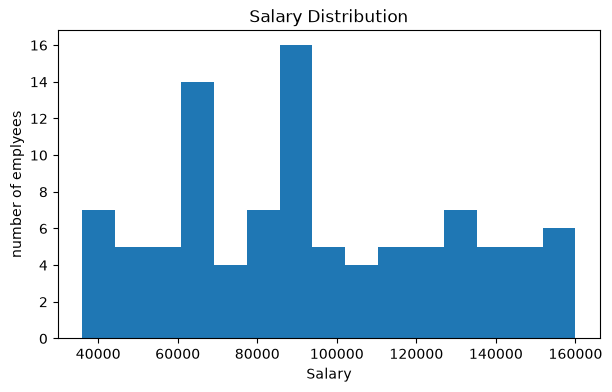

In [135]:
plt.figure(figsize=(7,4)) #This creates a new figure/canvas for your graph. 7- width 4 height
plt.hist(df["Salary"], bins=15) #means: Divide the range of salary values into 15 intervals (bins).
plt.xlabel("Salary")
plt.ylabel("number of emplyees")
plt.title("Salary Distribution")

plt.show()

# 10.2 Salary by department

(array([0, 1, 2, 3, 4]),
 [Text(0, 0, 'Finance'),
  Text(1, 0, 'HR'),
  Text(2, 0, 'IT'),
  Text(3, 0, 'Marketing'),
  Text(4, 0, 'Operations')])

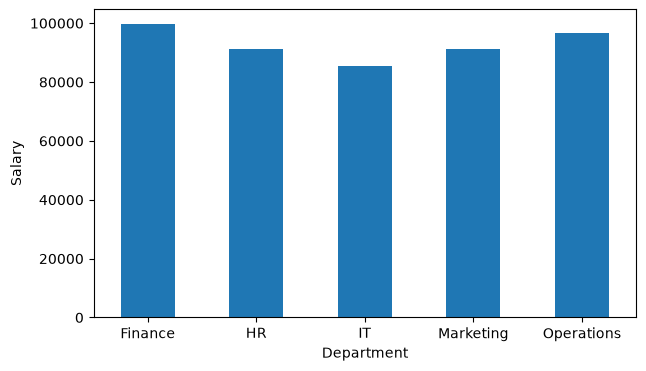

In [140]:
plt.figure(figsize=(7,4))
df.groupby("Department")["Salary"].mean().plot(kind="bar")
plt.xlabel("Department")
plt.ylabel("Salary")
plt.xticks(rotation=0)

# 0.3 Employee count by department

<Axes: xlabel='Department'>

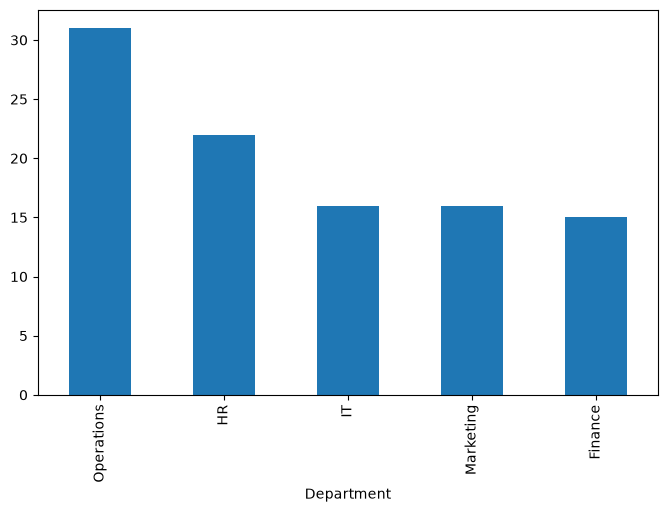

In [141]:
plt.figure(figsize=(8,5))
df["Department"].value_counts().plot(kind="bar")

# 10.4 Experience vs Salary

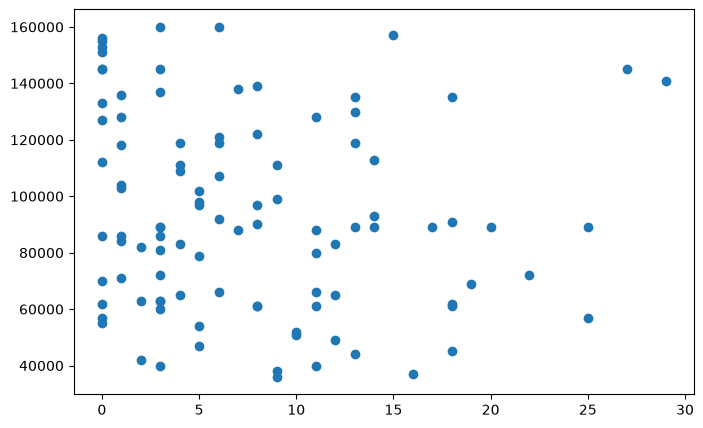

In [142]:
plt.figure(figsize=(8,5))
plt.scatter(df["Experience"],df["Salary"])

# salary BOX PLOT

{'whiskers': [<matplotlib.lines.Line2D at 0x75950586a900>,
 'caps': [<matplotlib.lines.Line2D at 0x759505868c20>,
 'boxes': [<matplotlib.lines.Line2D at 0x75950586a7b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7595058686e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x759505868830>],
 'means': []}

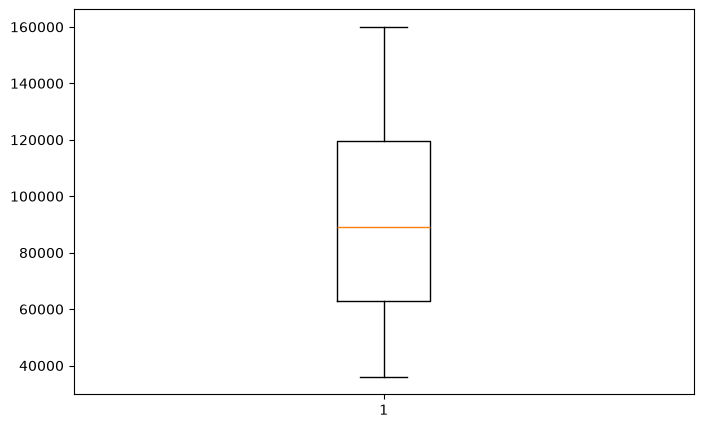

In [143]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Salary"])

In [144]:
df.to_csv(
    "../data/processed/employee_cleaned.csv",
    index=False
)

# 11 business insight

In [149]:
# 1. Department with highest average salary
df.groupby("Department")["Salary"].mean().sort_values(ascending=False)

Department
Finance       99666.666667
Operations    96806.451613
HR            91363.636364
Marketing     91187.500000
IT            85437.500000
Name: Salary, dtype: float64

In [150]:
#2. Department with most employees
df["Department"].value_counts()

Department
Operations    31
HR            22
IT            16
Marketing     16
Finance       15
Name: count, dtype: int64

In [151]:
#3. City with highest average salary
df.groupby("City")["Salary"].mean().sort_values(ascending=False)

City
Pune         100500.000000
Bangalore     98650.000000
Hyderabad     98555.555556
Mumbai        92214.285714
Chennai       76095.238095
Name: Salary, dtype: float64

dep with highest avf salary is finance 
dep with most employees is operations
city with highest avg salary is pune

# 12 conclusion

This project demonstrated an end-to-end employee data analysis workflow using Python.

Employee data was extracted from a PDF using Tabula and combined into a single Pandas DataFrame. The dataset was then inspected and cleaned by handling missing values, checking for duplicate records, validating data types, and performing basic data-quality checks.

NumPy and Pandas were used for statistical analysis and data manipulation. Exploratory Data Analysis was performed to understand employee demographics, salary distribution, departmental patterns, experience, and performance. Matplotlib and Seaborn were used to visualize important patterns and relationships in the data.

Finally, the analysis was used to generate business insights related to salary, departments, cities, experience, and employee performance.

This project provided practical experience with the complete data-analysis workflow, from raw PDF data extraction to data cleaning, analysis, visualization, and interpretation.